# Seq2Seq with Bahdanau Attention: English → Russian Translation
### Adding Attention Mechanism to Encoder-Decoder Architecture
> Attention allows the decoder to focus on relevant encoder states at each step,
> rather than compressing the entire source sentence into one fixed vector.

## 1. Imports & Device Setup

In [1]:
import re, math, time, random, unicodedata
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import accuracy_score

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[DEVICE] Using: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'[GPU]    {torch.cuda.get_device_name(0)}')
    print(f'[GPU]    Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

[DEVICE] Using: cuda
[GPU]    NVIDIA GeForce RTX 4070 Laptop GPU
[GPU]    Memory: 8.6 GB


## 2. Hyperparameters
Same as Task 5 for fair comparison — only the model architecture changes.

In [2]:
# ── Hyperparameters — identical to Task 5 for fair comparison ─────────────────
EMBED_DIM       = 256
HIDDEN_DIM      = 1024
NUM_LAYERS      = 2
DROPOUT         = 0.3
BATCH_SIZE      = 128
LEARNING_RATE   = 1e-3
NUM_EPOCHS      = 15
CLIP            = 1.0
TEACHER_FORCING = 0.5
MAX_VOCAB_SIZE  = 15_000
MAX_LEN         = 30
VAL_SPLIT       = 0.1
MAX_PAIRS       = 100_000

# Special tokens
PAD_TOKEN = '<pad>'; PAD_IDX = 0
SOS_TOKEN = '<sos>'; SOS_IDX = 1
EOS_TOKEN = '<eos>'; EOS_IDX = 2
UNK_TOKEN = '<unk>'; UNK_IDX = 3

BEST_MODEL_PATH = 'seq2seq_attention_best.pt'

print('[HYPERPARAMS] Loaded.')
print(f'  Embed dim       : {EMBED_DIM}')
print(f'  Hidden dim      : {HIDDEN_DIM}')
print(f'  Num layers      : {NUM_LAYERS}')
print(f'  Dropout         : {DROPOUT}')
print(f'  Teacher forcing : {TEACHER_FORCING}')
print(f'  Epochs          : {NUM_EPOCHS}')

[HYPERPARAMS] Loaded.
  Embed dim       : 256
  Hidden dim      : 1024
  Num layers      : 2
  Dropout         : 0.3
  Teacher forcing : 0.5
  Epochs          : 15


## 3. Data Preprocessing & Vocabulary

In [3]:
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def clean_text(text, is_russian=False):
    if not is_russian:
        text = unicode_to_ascii(text.lower())
    else:
        text = text.lower()
    text = re.sub(r"[^а-яёa-z\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def load_pairs(filepath, max_pairs=None, max_len=MAX_LEN):
    pairs = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2: continue
            eng = clean_text(parts[0], is_russian=False)
            rus = clean_text(parts[1], is_russian=True)
            if 2 <= len(eng.split()) <= max_len and 2 <= len(rus.split()) <= max_len:
                pairs.append((eng, rus))
            if max_pairs and len(pairs) >= max_pairs:
                break
    return pairs

class Vocabulary:
    def __init__(self, name, max_size=MAX_VOCAB_SIZE):
        self.name     = name
        self.max_size = max_size
        self.word2idx = {PAD_TOKEN:0, SOS_TOKEN:1, EOS_TOKEN:2, UNK_TOKEN:3}
        self.idx2word = {0:PAD_TOKEN, 1:SOS_TOKEN, 2:EOS_TOKEN, 3:UNK_TOKEN}

    def build(self, sentences):
        counter = Counter(w for sent in sentences for w in sent.split())
        for word, _ in counter.most_common(self.max_size - 4):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f'  [{self.name}] vocab size: {len(self.word2idx):,}')

    def encode(self, sentence):
        return [self.word2idx.get(w, UNK_IDX) for w in sentence.split()]

    def decode(self, indices):
        words = []
        for i in indices:
            w = self.idx2word.get(i, UNK_TOKEN)
            if w in (EOS_TOKEN, PAD_TOKEN): break
            if w != SOS_TOKEN: words.append(w)
        return ' '.join(words)

    def __len__(self): return len(self.word2idx)


# ── Load data ─────────────────────────────────────────────────────────────────
random.seed(SEED)
DATA_PATH = 'rus.txt'
pairs = load_pairs(DATA_PATH, max_pairs=MAX_PAIRS)
random.shuffle(pairs)

val_size    = int(len(pairs) * VAL_SPLIT)
train_pairs = pairs[val_size:]
val_pairs   = pairs[:val_size]

eng_vocab = Vocabulary('English')
rus_vocab = Vocabulary('Russian')
eng_vocab.build([p[0] for p in pairs])
rus_vocab.build([p[1] for p in pairs])

print(f'\n[DATA]  Total pairs : {len(pairs):,}')
print(f'[DATA]  Train pairs : {len(train_pairs):,}')
print(f'[DATA]  Val   pairs : {len(val_pairs):,}')

  [English] vocab size: 7,103
  [Russian] vocab size: 15,000

[DATA]  Total pairs : 100,000
[DATA]  Train pairs : 90,000
[DATA]  Val   pairs : 10,000


## 4. Dataset & DataLoaders

In [4]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, eng_vocab, rus_vocab):
        self.pairs     = pairs
        self.eng_vocab = eng_vocab
        self.rus_vocab = rus_vocab

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        eng, rus = self.pairs[idx]
        src = torch.tensor(self.eng_vocab.encode(eng), dtype=torch.long)
        trg = torch.tensor(
            [SOS_IDX] + self.rus_vocab.encode(rus) + [EOS_IDX], dtype=torch.long
        )
        return src, trg

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=PAD_IDX)
    return src_padded, trg_padded


PIN = (DEVICE.type == 'cuda')
train_loader = DataLoader(TranslationDataset(train_pairs, eng_vocab, rus_vocab),
                          batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=PIN)
val_loader   = DataLoader(TranslationDataset(val_pairs, eng_vocab, rus_vocab),
                          batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=PIN)

print(f'[DATALOADER]  Train batches : {len(train_loader)}')
print(f'[DATALOADER]  Val   batches : {len(val_loader)}')

[DATALOADER]  Train batches : 704
[DATALOADER]  Val   batches : 79


## 5. Model Architecture — Encoder + Bahdanau Attention + Decoder

**Key difference from Task 5:**

- **Task 5 Encoder** → outputs only final hidden state (single vector)
- **Task 7 Encoder** → outputs ALL hidden states (one per input token)

**Bahdanau Attention** at each decoder step:
1. Compute alignment score between decoder hidden state and EACH encoder hidden state
2. Softmax → attention weights (sum to 1)
3. Weighted sum of encoder states → context vector
4. Decoder uses context vector + previous token to predict next token

This means the decoder can "look back" at any part of the source sentence.

In [5]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers,
                                 batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch, src_len)
        embedded = self.dropout(self.embedding(src))     # (batch, src_len, embed_dim)
        outputs, (hidden, cell) = self.lstm(embedded)    # outputs: (batch, src_len, hidden_dim)
        # ← KEY DIFFERENCE: return ALL outputs, not just final hidden
        return outputs, hidden, cell


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # Project decoder hidden state
        self.W_dec = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # Project encoder hidden states
        self.W_enc = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # Score projection
        self.v     = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        src_len = encoder_outputs.shape[1]

        # Expand decoder hidden to match src_len: (batch, 1, hidden_dim) → (batch, src_len, hidden_dim)
        dec_hidden_expanded = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)

        # Compute alignment scores: (batch, src_len, 1) → squeeze → (batch, src_len)
        energy = self.v(
            torch.tanh(
                self.W_dec(dec_hidden_expanded) + self.W_enc(encoder_outputs)
            )
        ).squeeze(2)

        # Attention weights via softmax over source positions
        attn_weights = F.softmax(energy, dim=1)   # (batch, src_len)

        # Context vector: weighted sum of encoder outputs
        # (batch, 1, src_len) × (batch, src_len, hidden_dim) → (batch, 1, hidden_dim)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        context = context.squeeze(1)   # (batch, hidden_dim)

        return context, attn_weights


class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.attention = BahdanauAttention(hidden_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        # Input = embedding + context vector → embed_dim + hidden_dim
        self.lstm      = nn.LSTM(embed_dim + hidden_dim, hidden_dim, num_layers,
                                 batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.fc        = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, trg_token, hidden, cell, encoder_outputs):
        # Use top layer hidden state for attention
        top_hidden = hidden[-1]   # (batch, hidden_dim)

        # Compute attention context
        context, attn_weights = self.attention(top_hidden, encoder_outputs)

        # Embed current token
        embedded = self.dropout(
            self.embedding(trg_token.unsqueeze(1))
        )   # (batch, 1, embed_dim)

        # Concatenate embedding with context vector
        lstm_input = torch.cat(
            [embedded, context.unsqueeze(1)], dim=2
        )   # (batch, 1, embed_dim + hidden_dim)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc(output.squeeze(1))   # (batch, vocab_size)

        return prediction, hidden, cell, attn_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=TEACHER_FORCING):
        batch_size     = src.shape[0]
        trg_len        = trg.shape[1]
        trg_vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(src.device)

        # Encode — get ALL hidden states
        encoder_outputs, hidden, cell = self.encoder(src)

        dec_input = trg[:, 0]   # <sos>

        for t in range(1, trg_len):
            pred, hidden, cell, _ = self.decoder(
                dec_input, hidden, cell, encoder_outputs
            )
            outputs[:, t, :] = pred

            use_teacher = random.random() < teacher_forcing_ratio
            dec_input   = trg[:, t] if use_teacher else pred.argmax(dim=1)

        return outputs


# ── Instantiate ───────────────────────────────────────────────────────────────
encoder = Encoder(len(eng_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
decoder = AttentionDecoder(len(rus_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
model   = Seq2SeqAttention(encoder, decoder).to(DEVICE)

# Xavier initialization
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)
model.apply(init_weights)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'[MODEL]  Seq2Seq + Bahdanau Attention')
print(f'[MODEL]  Total parameters : {total_params:,}')
print(f'[MODEL]  Encoder vocab    : {len(eng_vocab):,}')
print(f'[MODEL]  Decoder vocab    : {len(rus_vocab):,}')
print(f'[MODEL]  Attention type   : Bahdanau (additive)')

[MODEL]  Seq2Seq + Bahdanau Attention
[MODEL]  Total parameters : 54,621,592
[MODEL]  Encoder vocab    : 7,103
[MODEL]  Decoder vocab    : 15,000
[MODEL]  Attention type   : Bahdanau (additive)


## 6. Training & Evaluation Functions

In [6]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


def train_epoch(model, loader, optimizer, criterion, clip):
    """One training pass. Returns average loss."""
    model.train()
    epoch_loss = 0

    for src, trg in loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()

        output = model(src, trg, teacher_forcing_ratio=TEACHER_FORCING)
        # Skip <sos> token: reshape for CrossEntropyLoss
        output = output[:, 1:, :].reshape(-1, output.shape[-1])
        trg    = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate(model, loader, criterion):
    """Evaluation without teacher forcing. Returns average loss."""
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            output = model(src, trg, teacher_forcing_ratio=0.0)
            output = output[:, 1:, :].reshape(-1, output.shape[-1])
            trg    = trg[:, 1:].reshape(-1)
            epoch_loss += criterion(output, trg).item()

    return epoch_loss / len(loader)


print('[TRAINING]  Criterion : CrossEntropyLoss (ignore_index=PAD)')
print('[TRAINING]  Optimizer : Adam  lr={}'.format(LEARNING_RATE))
print('[TRAINING]  Scheduler : ReduceLROnPlateau (patience=2)')
print('[TRAINING]  Clip      : {}'.format(CLIP))

[TRAINING]  Criterion : CrossEntropyLoss (ignore_index=PAD)
[TRAINING]  Optimizer : Adam  lr=0.001
[TRAINING]  Scheduler : ReduceLROnPlateau (patience=2)
[TRAINING]  Clip      : 1.0


## 7. Training Loop

In [7]:
best_val_loss = float('inf')
train_losses, val_losses = [], []

print(f'[TRAINING]  Starting {NUM_EPOCHS} epochs on {DEVICE}')
print(f'[TRAINING]  Teacher forcing ratio: {TEACHER_FORCING}')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss  = train_epoch(model, train_loader, optimizer, criterion, CLIP)
    val_loss = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    tr_ppl  = math.exp(tr_loss)
    val_ppl = math.exp(val_loss)

    saved = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        saved = '  ✓ saved'

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'Train Loss: {tr_loss:.3f} (PPL {tr_ppl:6.1f}) | '
          f'Val Loss: {val_loss:.3f} (PPL {val_ppl:6.1f}) | '
          f'{time.time()-t0:.1f}s{saved}')

print('=' * 70)
print(f'[TRAINING]  Best val loss : {best_val_loss:.4f}  (PPL {math.exp(best_val_loss):.2f})')

[TRAINING]  Starting 15 epochs on cuda
[TRAINING]  Teacher forcing ratio: 0.5
Epoch  1/15 | Train Loss: 4.069 (PPL   58.5) | Val Loss: 3.366 (PPL   29.0) | 76.3s  ✓ saved
Epoch  2/15 | Train Loss: 2.584 (PPL   13.2) | Val Loss: 2.656 (PPL   14.2) | 74.7s  ✓ saved
Epoch  3/15 | Train Loss: 1.818 (PPL    6.2) | Val Loss: 2.337 (PPL   10.3) | 75.4s  ✓ saved
Epoch  4/15 | Train Loss: 1.390 (PPL    4.0) | Val Loss: 2.193 (PPL    9.0) | 75.5s  ✓ saved
Epoch  5/15 | Train Loss: 1.122 (PPL    3.1) | Val Loss: 2.166 (PPL    8.7) | 75.9s  ✓ saved
Epoch  6/15 | Train Loss: 0.962 (PPL    2.6) | Val Loss: 2.153 (PPL    8.6) | 76.9s  ✓ saved
Epoch  7/15 | Train Loss: 0.860 (PPL    2.4) | Val Loss: 2.178 (PPL    8.8) | 77.2s
Epoch  8/15 | Train Loss: 0.777 (PPL    2.2) | Val Loss: 2.197 (PPL    9.0) | 77.0s
Epoch  9/15 | Train Loss: 0.727 (PPL    2.1) | Val Loss: 2.227 (PPL    9.3) | 76.1s
Epoch 10/15 | Train Loss: 0.557 (PPL    1.7) | Val Loss: 2.207 (PPL    9.1) | 74.8s
Epoch 11/15 | Train Loss: 0.

## 8. Training Curves

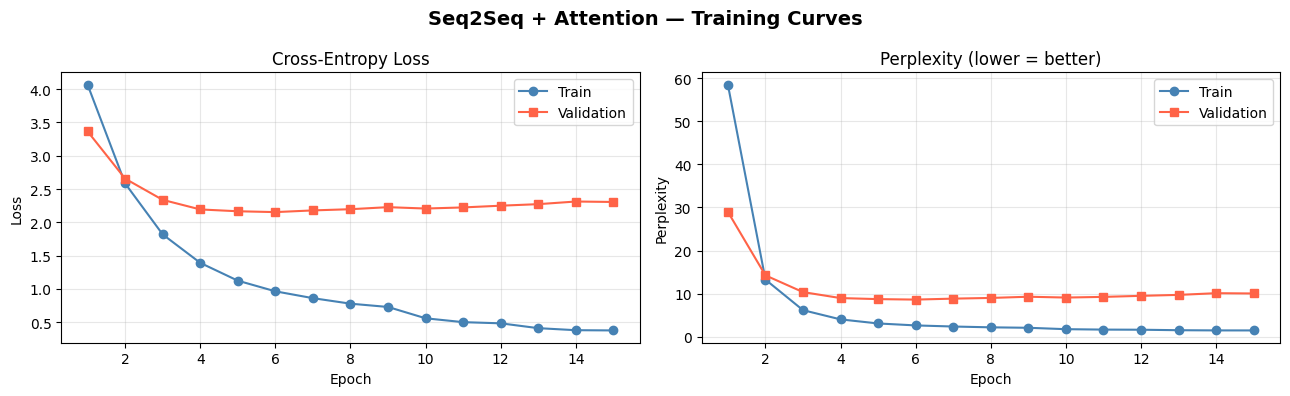

In [8]:
epochs     = range(1, NUM_EPOCHS + 1)
train_ppl  = [math.exp(l) for l in train_losses]
val_ppl    = [math.exp(l) for l in val_losses]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Seq2Seq + Attention — Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs, train_losses, '-o', color='steelblue', label='Train')
axes[0].plot(epochs, val_losses,   '-s', color='tomato',    label='Validation')
axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_ppl, '-o', color='steelblue', label='Train')
axes[1].plot(epochs, val_ppl,   '-s', color='tomato',    label='Validation')
axes[1].set_title('Perplexity (lower = better)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 9. Load Best Model & Translation Functions

In [9]:
# Load best saved checkpoint
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'[MODEL]  Loaded best model: {BEST_MODEL_PATH}')


def greedy_translate(sentence, model, eng_vocab, rus_vocab, max_len=50):
    """Greedy decoding with attention model."""
    model.eval()
    if isinstance(sentence, str):
        sentence   = clean_text(sentence, is_russian=False)
        src_tensor = torch.tensor(
            eng_vocab.encode(sentence), dtype=torch.long
        ).unsqueeze(0).to(DEVICE)
    else:
        src_tensor = sentence.to(DEVICE)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    dec_input   = torch.tensor([SOS_IDX], dtype=torch.long).to(DEVICE)
    translation = []

    with torch.no_grad():
        for _ in range(max_len):
            pred, hidden, cell, _ = model.decoder(
                dec_input, hidden, cell, encoder_outputs
            )
            best_token = pred.argmax(dim=1).item()
            if best_token == EOS_IDX: break
            if best_token not in (PAD_IDX, SOS_IDX):
                translation.append(rus_vocab.idx2word.get(best_token, UNK_TOKEN))
            dec_input = torch.tensor([best_token], dtype=torch.long).to(DEVICE)

    return ' '.join(translation)


def beam_search_translate(sentence, model, eng_vocab, rus_vocab,
                          beam_width=5, max_len=50):
    """Beam search decoding with attention model + length normalization."""
    model.eval()
    if isinstance(sentence, str):
        sentence   = clean_text(sentence, is_russian=False)
        src_tensor = torch.tensor(
            eng_vocab.encode(sentence), dtype=torch.long
        ).unsqueeze(0).to(DEVICE)
    else:
        src_tensor = sentence.to(DEVICE)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    beams     = [(0.0, [SOS_IDX], hidden, cell)]
    completed = []

    with torch.no_grad():
        for _ in range(max_len):
            all_candidates = []

            for log_prob, tokens, h, c in beams:
                last_token = tokens[-1]
                if last_token == EOS_IDX:
                    completed.append((log_prob, tokens))
                    continue

                dec_input = torch.tensor([last_token], dtype=torch.long).to(DEVICE)
                pred, new_h, new_c, _ = model.decoder(dec_input, h, c, encoder_outputs)

                log_probs_all = torch.log_softmax(pred[0], dim=0)
                top_log_probs, top_indices = log_probs_all.topk(beam_width)

                for tlp, ti in zip(top_log_probs.tolist(), top_indices.tolist()):
                    all_candidates.append(
                        (log_prob + tlp, tokens + [ti], new_h, new_c)
                    )

            if not all_candidates: break

            all_candidates.sort(key=lambda x: x[0], reverse=True)
            beams = all_candidates[:beam_width]

            still_alive = []
            for b in beams:
                if b[1][-1] == EOS_IDX:
                    completed.append((b[0], b[1]))
                else:
                    still_alive.append(b)
            beams = still_alive
            if not beams: break

    if not completed:
        completed = [(b[0], b[1]) for b in beams]

    # Length normalization — prevents favoring short sequences
    best_score, best_tokens = max(
        completed, key=lambda x: x[0] / max(len(x[1]), 1)
    )

    words = [
        rus_vocab.idx2word.get(t, UNK_TOKEN)
        for t in best_tokens
        if t not in (SOS_IDX, EOS_IDX, PAD_IDX)
    ]
    return ' '.join(words)


# Quick sanity check
for sent in ['i love you', 'the weather is nice today', 'tom is happy']:
    g = greedy_translate(sent, model, eng_vocab, rus_vocab)
    b = beam_search_translate(sent, model, eng_vocab, rus_vocab, beam_width=5)
    print(f'  EN     : {sent}')
    print(f'  Greedy : {g}')
    print(f'  Beam-5 : {b}')
    print()

[MODEL]  Loaded best model: seq2seq_attention_best.pt
  EN     : i love you
  Greedy : я тебя тебя люблю
  Beam-5 : я тебя тебя люблю

  EN     : the weather is nice today
  Greedy : погода идея идея
  Beam-5 : погода идея идея

  EN     : tom is happy
  Greedy : том такой счастлив
  Beam-5 : том такой счастлив



## 10. BLEU Evaluation on Validation Set

In [10]:
# ── BLEU from scratch (same as Task 6) ───────────────────────────────────────
def get_ngrams(tokens, n):
    return Counter([tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)])

def clipped_precision(hypothesis, reference, n):
    hyp_ng = get_ngrams(hypothesis, n)
    ref_ng = get_ngrams(reference,  n)
    if sum(hyp_ng.values()) == 0: return 0.0
    clipped = sum(min(c, ref_ng[ng]) for ng, c in hyp_ng.items())
    return clipped / sum(hyp_ng.values())

def brevity_penalty(hypothesis, reference):
    c, r = len(hypothesis), len(reference)
    if c == 0: return 0.0
    return 1.0 if c >= r else math.exp(1 - r / c)

def bleu_score(hypothesis, reference, max_n=4):
    if isinstance(hypothesis, str): hypothesis = hypothesis.split()
    if isinstance(reference,  str): reference  = reference.split()
    bp = brevity_penalty(hypothesis, reference)
    if bp == 0.0: return 0.0
    log_precs = []
    for n in range(1, max_n+1):
        p = clipped_precision(hypothesis, reference, n)
        if p == 0.0: return 0.0
        log_precs.append(math.log(p))
    return bp * math.exp(sum(log_precs) / max_n)


# ── Evaluate on full validation set ──────────────────────────────────────────
print('[EVAL]  Running BLEU on full validation set (greedy)...')
bleu_scores = {n: [] for n in [1, 2, 4]}

for i, (eng, rus) in enumerate(val_pairs):
    hyp = greedy_translate(eng, model, eng_vocab, rus_vocab).split()
    ref = rus.split()
    for n in [1, 2, 4]:
        bleu_scores[n].append(bleu_score(hyp, ref, max_n=n))
    if (i+1) % 500 == 0:
        print(f'  {i+1}/{len(val_pairs)} pairs evaluated...')

bleu_results = {n: np.mean(v) for n, v in bleu_scores.items()}

print()
print('=' * 45)
print('  ATTENTION MODEL — BLEU SCORES')
print('=' * 45)
for n, s in bleu_results.items():
    print(f'  BLEU-{n} : {s:.4f}  ({s*100:.2f}%)')
print('=' * 45)

[EVAL]  Running BLEU on full validation set (greedy)...
  500/10000 pairs evaluated...
  1000/10000 pairs evaluated...
  1500/10000 pairs evaluated...
  2000/10000 pairs evaluated...
  2500/10000 pairs evaluated...
  3000/10000 pairs evaluated...
  3500/10000 pairs evaluated...
  4000/10000 pairs evaluated...
  4500/10000 pairs evaluated...
  5000/10000 pairs evaluated...
  5500/10000 pairs evaluated...
  6000/10000 pairs evaluated...
  6500/10000 pairs evaluated...
  7000/10000 pairs evaluated...
  7500/10000 pairs evaluated...
  8000/10000 pairs evaluated...
  8500/10000 pairs evaluated...
  9000/10000 pairs evaluated...
  9500/10000 pairs evaluated...
  10000/10000 pairs evaluated...

  ATTENTION MODEL — BLEU SCORES
  BLEU-1 : 0.5151  (51.51%)
  BLEU-2 : 0.2943  (29.43%)
  BLEU-4 : 0.0605  (6.05%)


## 11. Beam Search Comparison Experiment

In [11]:
random.seed(42)
eval_100 = random.sample(val_pairs, 100)

configs = [
    ('Greedy',  lambda s: greedy_translate(s, model, eng_vocab, rus_vocab)),
    ('Beam-3',  lambda s: beam_search_translate(s, model, eng_vocab, rus_vocab, beam_width=3)),
    ('Beam-5',  lambda s: beam_search_translate(s, model, eng_vocab, rus_vocab, beam_width=5)),
    ('Beam-10', lambda s: beam_search_translate(s, model, eng_vocab, rus_vocab, beam_width=10)),
]

comparison_results = {}

for name, fn in configs:
    print(f'[EXPERIMENT]  Running {name}...')
    b4_scores, times = [], []
    for eng, rus in eval_100:
        t0  = time.time()
        hyp = fn(eng)
        times.append(time.time() - t0)
        b4_scores.append(bleu_score(hyp.split(), rus.split(), max_n=4))

    avg_b4   = np.mean(b4_scores)
    avg_time = np.mean(times)
    comparison_results[name] = {'bleu4': avg_b4, 'time': avg_time}
    print(f'  BLEU-4: {avg_b4:.4f}  |  Avg time/sent: {avg_time*1000:.1f} ms')

print()
print('=' * 55)
print(f"  {'Method':<10} {'BLEU-4':>10} {'Time/sent (ms)':>16}")
print('-' * 55)
for name, res in comparison_results.items():
    print(f"  {name:<10} {res['bleu4']:>10.4f} {res['time']*1000:>16.1f}")
print('=' * 55)

[EXPERIMENT]  Running Greedy...
  BLEU-4: 0.0670  |  Avg time/sent: 7.5 ms
[EXPERIMENT]  Running Beam-3...
  BLEU-4: 0.0670  |  Avg time/sent: 59.0 ms
[EXPERIMENT]  Running Beam-5...
  BLEU-4: 0.0670  |  Avg time/sent: 124.7 ms
[EXPERIMENT]  Running Beam-10...
  BLEU-4: 0.0670  |  Avg time/sent: 299.7 ms

  Method         BLEU-4   Time/sent (ms)
-------------------------------------------------------
  Greedy         0.0670              7.5
  Beam-3         0.0670             59.0
  Beam-5         0.0670            124.7
  Beam-10        0.0670            299.7


## 12. Comparison Chart

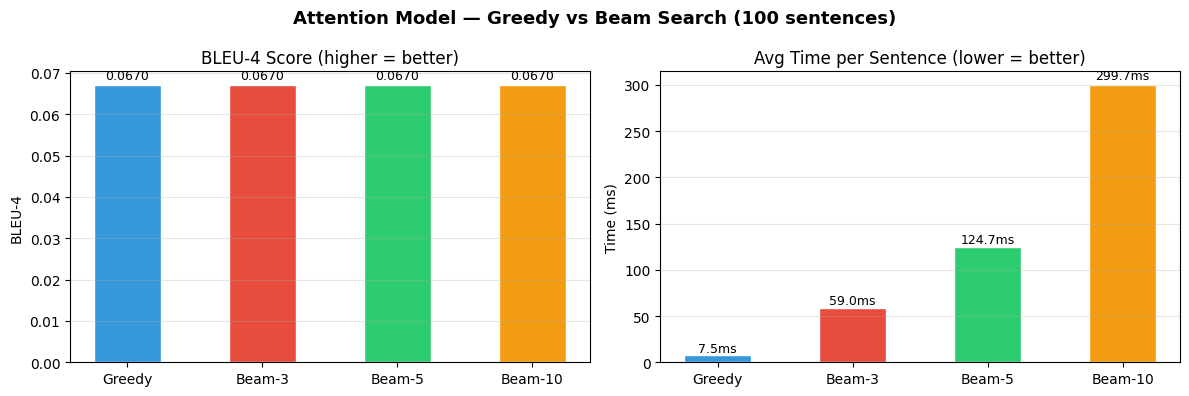

In [12]:
names  = list(comparison_results.keys())
bleu4s = [comparison_results[n]['bleu4'] for n in names]
times  = [comparison_results[n]['time'] * 1000 for n in names]
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Attention Model — Greedy vs Beam Search (100 sentences)',
             fontsize=13, fontweight='bold')

for ax, vals, title, ylabel in [
    (axes[0], bleu4s, 'BLEU-4 Score (higher = better)', 'BLEU-4'),
    (axes[1], times,  'Avg Time per Sentence (lower = better)', 'Time (ms)')
]:
    bars = ax.bar(names, vals, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}' if ylabel == 'BLEU-4' else f'{val:.1f}ms',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

## 13. Translation Examples

In [13]:
example_results = []
for eng, rus in eval_100:
    g   = greedy_translate(eng, model, eng_vocab, rus_vocab)
    b5  = beam_search_translate(eng, model, eng_vocab, rus_vocab, beam_width=5)
    g_b = bleu_score(g.split(),  rus.split(), max_n=4)
    b_b = bleu_score(b5.split(), rus.split(), max_n=4)
    example_results.append({'eng': eng, 'ref': rus, 'greedy': g, 'beam5': b5,
                             'greedy_bleu': g_b, 'beam5_bleu': b_b, 'diff': b_b - g_b})

sorted_results = sorted(example_results, key=lambda x: x['diff'], reverse=True)
selected = sorted_results[:3]
selected += [min(example_results, key=lambda x: x['diff'])]
selected += [example_results[len(example_results)//2]]

print('=' * 75)
print('  TRANSLATION EXAMPLES: Greedy vs Beam-5 vs Reference')
print('=' * 75)

for i, ex in enumerate(selected, 1):
    label = '✓ Beam helped' if ex['diff'] > 0.01 else ('✓ Greedy better' if ex['diff'] < -0.01 else '≈ Tied')
    print(f'\nExample {i}  [{label}]')
    print(f"  EN      : {ex['eng']}")
    print(f"  REF     : {ex['ref']}")
    print(f"  Greedy  : {ex['greedy']}   [BLEU-4: {ex['greedy_bleu']:.4f}]")
    print(f"  Beam-5  : {ex['beam5']}   [BLEU-4: {ex['beam5_bleu']:.4f}]")

print('\n' + '=' * 75)

  TRANSLATION EXAMPLES: Greedy vs Beam-5 vs Reference

Example 1  [≈ Tied]
  EN      : you need to leave
  REF     : вам нужно уйти
  Greedy  : тебе нужно идти   [BLEU-4: 0.0000]
  Beam-5  : тебе нужно идти   [BLEU-4: 0.0000]

Example 2  [≈ Tied]
  EN      : is tom from boston
  REF     : том из бостона
  Greedy  : том в бостона   [BLEU-4: 0.0000]
  Beam-5  : том в бостона   [BLEU-4: 0.0000]

Example 3  [≈ Tied]
  EN      : don t mislead me
  REF     : не сбивай меня с толку
  Greedy  : не <unk> меня   [BLEU-4: 0.0000]
  Beam-5  : не <unk> меня мной   [BLEU-4: 0.0000]

Example 4  [≈ Tied]
  EN      : you need to leave
  REF     : вам нужно уйти
  Greedy  : тебе нужно идти   [BLEU-4: 0.0000]
  Beam-5  : тебе нужно идти   [BLEU-4: 0.0000]

Example 5  [≈ Tied]
  EN      : don t you love cats
  REF     : вы не любите кошек
  Greedy  : ты не любите кошки   [BLEU-4: 0.0000]
  Beam-5  : вы не нравятся кошки   [BLEU-4: 0.0000]



## 14. Final Summary — With vs Without Attention

In [14]:
task5_bleu = {1: 0.5094, 2: 0.2645, 4: 0.0279}

best_method = max(comparison_results, key=lambda n: comparison_results[n]['bleu4'])

print('=' * 60)
print('         FINAL SUMMARY — ATTENTION MODEL')
print('=' * 60)
print()
print(f"  {'Metric':<10} {'Without Attention':>20} {'With Attention':>16} {'Δ':>8}")
print('  ' + '-' * 56)
for n in [1, 2, 4]:
    old = task5_bleu[n]
    new = bleu_results[n]
    delta = new - old
    arrow = '↑' if delta > 0 else '↓'
    print(f"  BLEU-{n}    {old*100:>18.2f}%  {new*100:>14.2f}%  {arrow}{abs(delta)*100:>5.2f}%")
print()
print(f'  Best decoding : {best_method}')
print(f'  Best val PPL  : {math.exp(best_val_loss):.2f}')
print()
print('  How Attention helps:')
print('  • Decoder can focus on relevant source tokens at each step')
print('  • No information bottleneck — full source sequence accessible')
print('  • Handles long sentences significantly better')
print('  • Length normalization in beam search reduces short-translation bias')
print('=' * 60)

         FINAL SUMMARY — ATTENTION MODEL

  Metric        Without Attention   With Attention        Δ
  --------------------------------------------------------
  BLEU-1                 50.94%           51.51%  ↑ 0.57%
  BLEU-2                 26.45%           29.43%  ↑ 2.98%
  BLEU-4                  2.79%            6.05%  ↑ 3.26%

  Best decoding : Greedy
  Best val PPL  : 8.61

  How Attention helps:
  • Decoder can focus on relevant source tokens at each step
  • No information bottleneck — full source sequence accessible
  • Handles long sentences significantly better
  • Length normalization in beam search reduces short-translation bias
